In [1]:
"""
Aggregate 4 cell-type comparison TSV files into one matrix and plot a heatmap.

Each TSV is expected to look like:

    celltype_semi_manual    B cell    CD14 monocyte    CD4 T cell    ...
    DC                      0         159              6             ...
    B cell                  122       17               0             ...
    ...

i.e. the first column is the row label (e.g. manually annotated cell type)
and the remaining columns are counts against another labeling scheme
(e.g. automated/predicted cell type).

Usage:
    python aggregate_celltype_heatmap.py file1.tsv file2.tsv file3.tsv file4.tsv \
        --outdir /mnt/user-data/outputs --normalize row
"""

import argparse
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def load_matrix(path: str) -> pd.DataFrame:
    """Load one TSV into a DataFrame indexed by the first column."""
    df = pd.read_csv(path, sep="\t", index_col=0)
    df.index.name = "row_label"
    df.columns.name = "col_label"
    # Make sure everything is numeric (coerce, then fill any bad parses with 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    return df


def aggregate_matrices(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    """
    Sum a list of (possibly differently-shaped) matrices, aligning on the
    union of row and column labels. Missing entries are treated as 0.
    """
    all_rows = sorted(set().union(*[set(d.index) for d in dfs]))
    all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

    aligned = [
        d.reindex(index=all_rows, columns=all_cols, fill_value=0) for d in dfs
    ]

    total = aligned[0].copy()
    for d in aligned[1:]:
        total = total.add(d, fill_value=0)

    return total.astype(int)


def normalize_matrix(df: pd.DataFrame, how: str | None) -> pd.DataFrame:
    """Optionally normalize counts to proportions."""
    if how is None or how == "none":
        return df
    if how == "row":
        return df.div(df.sum(axis=1).replace(0, 1), axis=0)
    if how == "col":
        return df.div(df.sum(axis=0).replace(0, 1), axis=1)
    if how == "all":
        return df / df.values.sum()
    raise ValueError(f"Unknown normalization: {how}")


def plot_heatmap(df: pd.DataFrame, out_path: Path, normalize: str | None, title: str):
    plt.figure(figsize=(1.0 * df.shape[1] + 3, 0.6 * df.shape[0] + 3))

    fmt = ".0f" if normalize in (None, "none") else ".2f"
    cmap = "viridis" if normalize in (None, "none") else "magma"

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "count" if normalize in (None, "none") else "proportion"},
    )
    ax.set_xlabel("Predicted / comparison label")
    ax.set_ylabel("Manual / reference label")
    ax.set_title(title)
    plt.tight_layout()
    #plt.savefig(out_path, dpi=200)
    #plt.close()
    print(f"Saved heatmap to {out_path}")



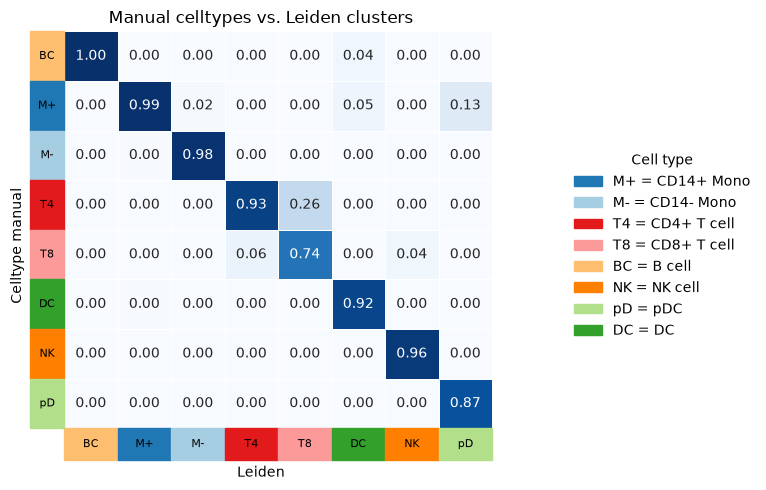

In [11]:
celltype1 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/crosstab.tsv')
celltype2 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/crosstab.tsv')
celltype3 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/crosstab.tsv')
celltype4 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/crosstab.tsv')
agg = aggregate_matrices([celltype1, celltype2, celltype3, celltype4])
agg = agg.drop(index='Megakaryocytes', columns='Megakaryocytes', errors='ignore')
agg = normalize_matrix(agg, 'col')


pal = {
    'CD14+ Mono': (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
    'CD14- Mono': (0.6509803921568628, 0.807843137254902, 0.8901960784313725),
    'CD4+ T cell': (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
    'CD8+ T cell': (0.984313725490196, 0.6039215686274509, 0.6),
    'B cell': (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
    'NK cell': (1.0, 0.4980392156862745, 0.0),
    'pDC': (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
    'DC': (0.2, 0.6274509803921569, 0.17254901960784313),
}

acronyms = {
    'CD14+ Mono': 'M+',
    'CD14- Mono': 'M-',
    'CD4+ T cell': 'T4',
    'CD8+ T cell': 'T8',
    'B cell': 'BC',
    'NK cell': 'NK',
    'pDC': 'pD',
    'DC': 'DC',
}

fig, ax = plt.subplots(1,1, figsize=(8, 5))

sns.heatmap(
    agg,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    fmt=".2f",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
ax.set_xlabel("Leiden")
ax.set_ylabel("Celltype manual")

n_rows, n_cols = agg.shape
bar_frac = 0.08  # thickness of the color strip, relative to axis size — tweak to taste

for j, col_label in enumerate(agg.columns):
    color = pal.get(col_label, 'grey')
    ax.add_patch(plt.Rectangle(
        (j, n_rows), 1, n_rows * bar_frac,
        color=color, clip_on=False, transform=ax.transData,
    ))
    ax.text(
        j + 0.5, n_rows + n_rows * bar_frac / 2, acronyms.get(col_label, '??'),
        ha='center', va='center', fontsize=8, clip_on=False,
    )

for i, row_label in enumerate(agg.index):
    color = pal.get(row_label, 'grey')
    ax.add_patch(plt.Rectangle(
        (-n_cols * bar_frac, i), n_cols * bar_frac, 1,
        color=color, clip_on=False, transform=ax.transData,
    ))
    ax.text(
        -n_cols * bar_frac / 2, i + 0.5, acronyms.get(row_label, '??'),
        ha='center', va='center', fontsize=8, clip_on=False,
    )

# extend the axis limits so the strips are visible outside the heatmap body
ax.set_xlim(-n_cols * bar_frac, n_cols)
ax.set_ylim(n_rows + n_rows * bar_frac, 0)

import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color=color, label=f"{acronyms.get(label, '??')} = {label}")
    for label, color in pal.items()
]
ax.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=False,
    title="Cell type",
)
ax.set_title('Manual celltypes vs. Leiden clusters')
plt.tight_layout()
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/blood_leiden_manual.pdf')


In [8]:
celltype1 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/celltype_rw_crosstab.tsv')
celltype2 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/celltype_rw_crosstab.tsv')
celltype3 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/celltype_rw_crosstab.tsv')
celltype4 = load_matrix('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/celltype_rw_crosstab.tsv')
agg = aggregate_matrices([celltype1, celltype2, celltype3, celltype4])
agg = agg.drop(index='Megakaryocytes', columns='Megakaryocytes', errors='ignore')
agg = normalize_matrix(agg, 'col')

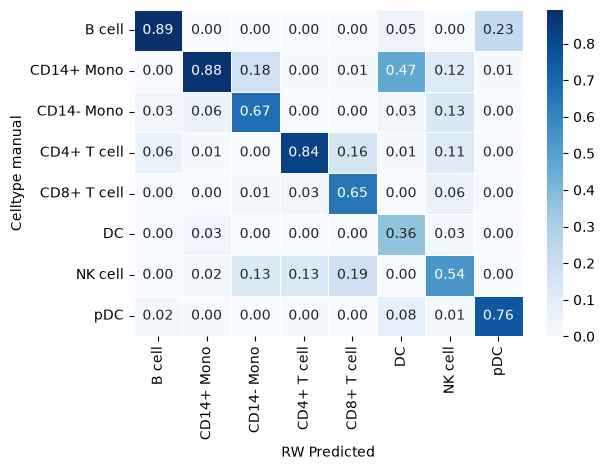

In [10]:
ax = sns.heatmap(
    agg,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
        fmt=".2f",
)
ax.set_xlabel("RW Predicted")
ax.set_ylabel("Celltype manual")
plt.tight_layout()